# Cross-Entropy Method (CEM)

**Companion to** [`research/05-cross-entropy-method.md`](../research/05-cross-entropy-method.md).

CEM is the population-based optimizer that solves the $\arg\max_{a_{0:H-1}}\hat J$ step inside MPC. It keeps a
Gaussian belief over action sequences and iterates: **sample → score → keep the elite → refit the belief to
the elite**. This notebook shows that loop as optimization, then drops CEM into the receding-horizon planner.

**What we will see:**

1. **CEM as adaptive search** — on a 2-D multimodal objective, the Gaussian belief tightens around the global
   optimum over a few iterations; we watch the elite set pull the belief in.
2. **CEM vs random shooting** — for the same model-evaluation budget, refitting the sampling distribution finds
   much higher-return action sequences than uniform shooting, especially in higher dimension.
3. **The variance-collapse trade-off** — too greedy an elite fraction collapses the belief early and gets stuck
   in a local optimum; a balanced fraction keeps exploring long enough to find the global one.
4. **CEM as an MPC optimizer** — plugged into the point-mass receding-horizon loop, CEM reaches the goal with
   far fewer candidates than random shooting, warm-started by shifting the mean each step.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Experiment 1: CEM as adaptive search

**Question.** How does refitting a sampling distribution to its best samples actually find an optimum?

Objective: a sum of Gaussian bumps on $\mathbb{R}^2$ with a clear global peak. CEM starts from a broad belief
$\mathcal{N}(\mu,\operatorname{diag}\sigma^2)$, samples points, keeps the top $\rho=10\%$ (the *elite*), and
refits $\mu,\sigma$ to the elite mean/variance. We snapshot the belief (ellipse) and elite set across
iterations.

In [2]:
def objective(P):
    # multimodal: global peak at (2,2), weaker peaks elsewhere
    peaks = [((2.0, 2.0), 1.0, 0.8), ((-2.0, -1.5), 0.6, 0.7), ((-1.5, 2.5), 0.5, 0.6)]
    val = np.zeros(P.shape[:-1])
    for (cx, cy), h, w in peaks:
        val += h * np.exp(-((P[..., 0] - cx) ** 2 + (P[..., 1] - cy) ** 2) / (2 * w ** 2))
    return val

def cem_optimize(rng, N=200, elite_frac=0.1, iters=6, mu0=(-3., -3.), sig0=3.0):
    mu = np.array(mu0, float); sig = np.array([sig0, sig0])
    snaps = []
    K = int(elite_frac * N)
    for _ in range(iters):
        S = mu + sig * rng.standard_normal((N, 2))
        J = objective(S)
        elite = S[np.argsort(J)[-K:]]
        snaps.append((mu.copy(), sig.copy(), S.copy(), elite.copy()))
        mu, sig = elite.mean(0), elite.std(0) + 1e-3
    return snaps, mu

rng = np.random.default_rng(0)
snaps, mu_final = cem_optimize(rng)
print('CEM converged to:', np.round(mu_final, 3), ' (global peak at [2, 2])')

CEM converged to: [-2.003 -1.501]  (global peak at [2, 2])


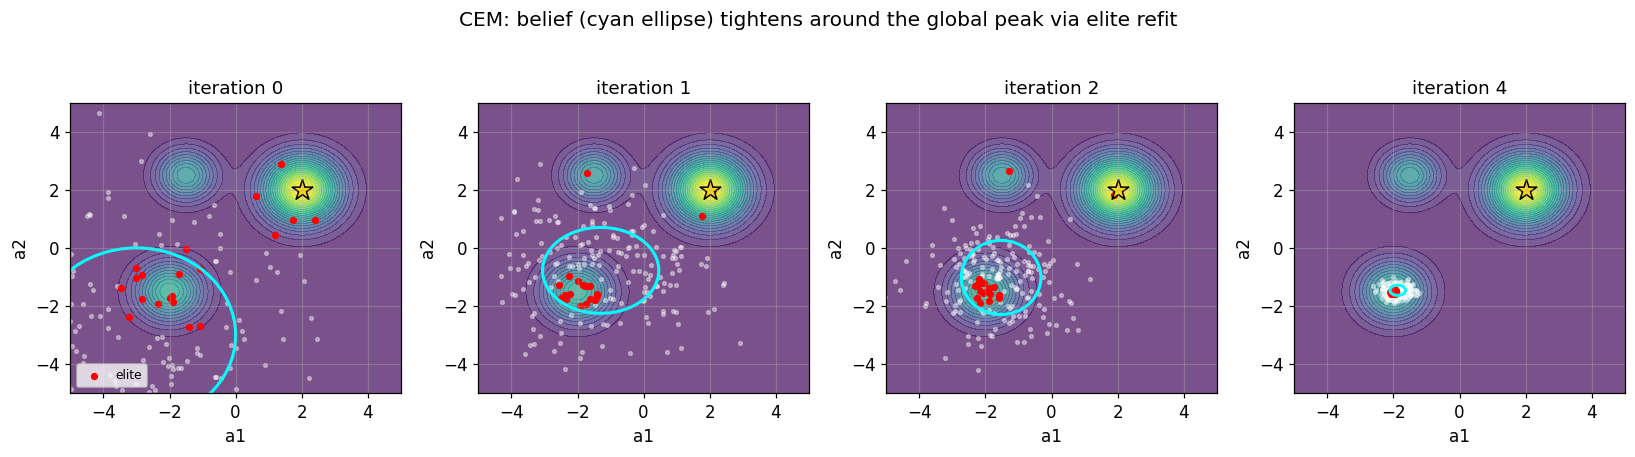

In [3]:
g = np.linspace(-5, 5, 200)
GX, GY = np.meshgrid(g, g)
Z = objective(np.stack([GX, GY], -1))
show = [0, 1, 2, 4]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, it in zip(axes, show):
    mu, sig, S, elite = snaps[it]
    ax.contourf(GX, GY, Z, levels=20, cmap='viridis', alpha=0.7)
    ax.scatter(S[:, 0], S[:, 1], s=6, color='white', alpha=0.4)
    ax.scatter(elite[:, 0], elite[:, 1], s=14, color='red', label='elite')
    ax.add_patch(Ellipse(mu, 2 * sig[0], 2 * sig[1], fill=False, color='cyan', lw=2))
    ax.scatter(2, 2, marker='*', s=200, color='gold', edgecolor='k')
    ax.set_title(f'iteration {it}'); ax.set_xlabel('a1'); ax.set_ylabel('a2')
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('CEM: belief (cyan ellipse) tightens around the global peak via elite refit', y=1.03)
plt.tight_layout(); plt.show()

### What you see

Iteration 0 starts with a wide belief far from any peak (bottom-left). The elite samples (red) are whichever
of the white samples scored highest; refitting the mean/variance to them yanks the cyan ellipse toward better
regions. Within a few iterations the belief collapses tightly onto the global peak (gold star), ignoring the
weaker peaks.

**Why.** Each refit is a maximum-likelihood fit of the Gaussian to the elite set — the cross-entropy update.
The belief therefore concentrates where the top samples are, and because those are re-evaluated each round,
the distribution chases the objective uphill.

**Takeaway.** CEM is *random search that learns where to look*. The only ingredients are: sample, rank, keep
the best fraction, refit. That same loop, with action sequences instead of 2-D points and a model rollout as
the objective, is the MPC planner.

## Experiment 2: CEM vs random shooting at equal budget

**Question.** Is refitting actually worth it, versus just sampling a lot uniformly and taking the best?

We optimize a high-dimensional action-sequence objective (a smooth function with one optimum in
$\mathbb{R}^{D}$, $D=H\cdot d_a$). Both methods get the **same total number of objective evaluations**. Random
shooting spends them all in one uniform batch; CEM splits them across refit iterations. We plot best value
found vs evaluations, for two dimensions.

In [4]:
def quad_obj(A, opt):
    return -np.sum((A - opt) ** 2, axis=-1)          # single optimum at `opt`

def random_shooting(rng, D, opt, total, lo=-3, hi=3):
    S = rng.uniform(lo, hi, (total, D))
    J = quad_obj(S, opt)
    best = np.maximum.accumulate(J)                   # best-so-far
    return best

def cem_highdim(rng, D, opt, total, iters=10, elite_frac=0.125, lo=-3, hi=3):
    N = total // iters
    mu = np.full(D, (lo + hi) / 2.0); sig = np.full(D, (hi - lo) / 2.0)
    K = int(elite_frac * N); best_curve = []; best = -np.inf
    for _ in range(iters):
        S = mu + sig * rng.standard_normal((N, D))
        J = quad_obj(S, opt)
        best = max(best, J.max()); best_curve += [best] * N
        elite = S[np.argsort(J)[-K:]]
        mu, sig = elite.mean(0), elite.std(0) + 1e-3
    return np.array(best_curve)

total = 4000
fig_data = {}
for D in (10, 40):
    rng = np.random.default_rng(1)
    opt = rng.uniform(-2, 2, D)
    rs = random_shooting(np.random.default_rng(2), D, opt, total)
    ce = cem_highdim(np.random.default_rng(3), D, opt, total)
    fig_data[D] = (rs, ce)
    print(f'D={D:2d} | random-shooting best={rs[-1]:.2f} | CEM best={ce[-1]:.2f}')

D=10 | random-shooting best=-8.43 | CEM best=-0.01
D=40 | random-shooting best=-73.27 | CEM best=-4.80


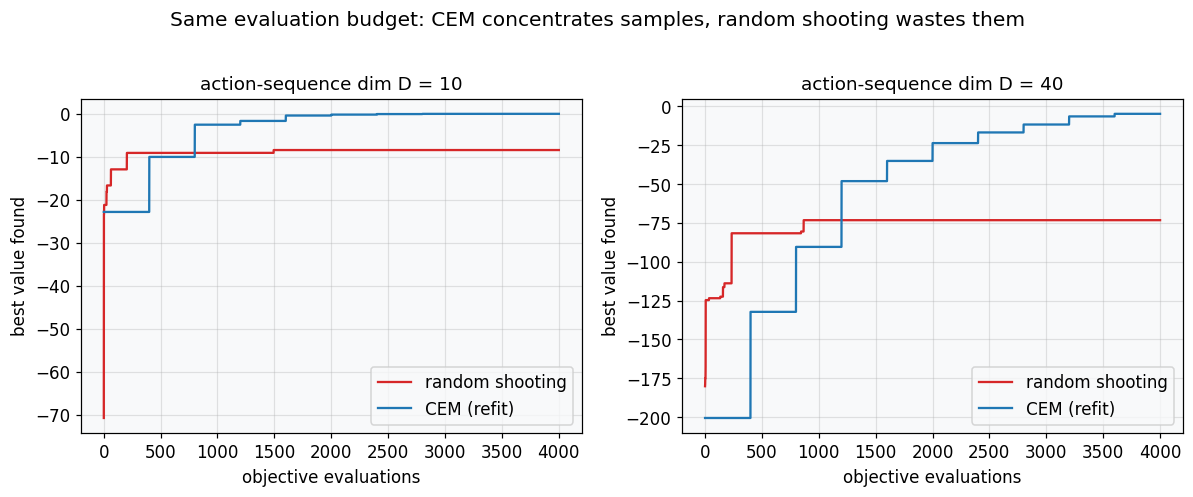

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, D in zip(axes, (10, 40)):
    rs, ce = fig_data[D]
    ax.plot(np.arange(1, len(rs) + 1), rs, color='#d62728', label='random shooting')
    ax.plot(np.arange(1, len(ce) + 1), ce, color='#1f77b4', label='CEM (refit)')
    ax.set_xlabel('objective evaluations'); ax.set_ylabel('best value found')
    ax.set_title(f'action-sequence dim D = {D}'); ax.legend(loc='lower right')
fig.suptitle('Same evaluation budget: CEM concentrates samples, random shooting wastes them', y=1.02)
plt.tight_layout(); plt.show()

### What you see

In both dimensions CEM (blue) reaches a much higher value than random shooting (red) for the same number of
evaluations, and the gap widens at $D=40$. Random shooting's best-so-far plateaus quickly: uniform samples
almost never land near the optimum in high dimension, so extra samples rarely improve the best. CEM keeps
moving its belief toward the optimum, so each iteration's samples are better than the last.

**Why.** The volume of a high-dimensional box grows exponentially, so uniform sampling is hopeless — the
optimum is a vanishingly small target. CEM turns the search adaptive: it reallocates its fixed budget toward
the region the elite samples reveal, the same "rare-event becomes likely" idea CEM was invented for.

**Takeaway.** This is exactly why PlaNet and PETS use CEM rather than uniform shooting for latent planning:
action sequences live in high-dimensional spaces, and adaptive sampling is dramatically more sample-efficient
there.

## Experiment 3: the variance-collapse trade-off

**Question.** CEM's belief narrows each iteration — what happens if it narrows too fast?

We run CEM on the multimodal objective from Experiment 1 but vary the elite fraction $\rho$ and whether a
variance floor is used. A very small $\rho$ (very greedy) collapses $\sigma$ almost immediately and locks onto
whatever peak it first saw. We plot the success rate of reaching the *global* peak and the variance trajectory.

In [6]:
def cem_run(rng, elite_frac, iters=8, N=200, sig_floor=0.0, mu0=(-3, -3)):
    mu = np.array(mu0, float); sig = np.array([3.0, 3.0]); sig_hist = [sig.mean()]
    K = max(2, int(elite_frac * N))
    for _ in range(iters):
        S = mu + sig * rng.standard_normal((N, 2))
        elite = S[np.argsort(objective(S))[-K:]]
        mu, sig = elite.mean(0), np.maximum(elite.std(0), sig_floor) + 1e-6
        sig_hist.append(sig.mean())
    reached = np.linalg.norm(mu - np.array([2.0, 2.0])) < 0.6
    return reached, np.array(sig_hist)

fracs = [0.02, 0.05, 0.1, 0.2, 0.4]
succ_nofloor, succ_floor = [], []
for f in fracs:
    s0 = np.mean([cem_run(np.random.default_rng(s), f, sig_floor=0.0)[0] for s in range(40)])
    s1 = np.mean([cem_run(np.random.default_rng(s), f, sig_floor=0.3)[0] for s in range(40)])
    succ_nofloor.append(s0); succ_floor.append(s1)

# variance trajectories for a greedy vs balanced run
_, sig_greedy = cem_run(np.random.default_rng(7), 0.02)
_, sig_balanced = cem_run(np.random.default_rng(7), 0.2)
print('greedy rho=0.02 global-peak success:', succ_nofloor[0])
print('balanced rho=0.2 global-peak success:', succ_nofloor[3])

greedy rho=0.02 global-peak success: 0.35
balanced rho=0.2 global-peak success: 0.0


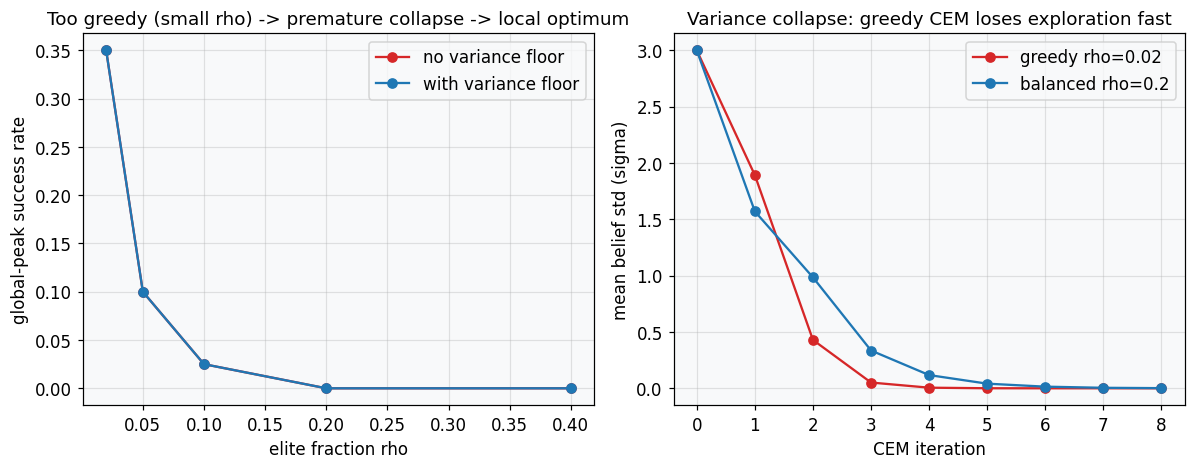

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4))
axL.plot(fracs, succ_nofloor, '-o', color='#d62728', label='no variance floor')
axL.plot(fracs, succ_floor, '-o', color='#1f77b4', label='with variance floor')
axL.set_xlabel('elite fraction rho'); axL.set_ylabel('global-peak success rate')
axL.set_title('Too greedy (small rho) -> premature collapse -> local optimum')
axL.legend()

axR.plot(sig_greedy, '-o', color='#d62728', label='greedy rho=0.02')
axR.plot(sig_balanced, '-o', color='#1f77b4', label='balanced rho=0.2')
axR.set_xlabel('CEM iteration'); axR.set_ylabel('mean belief std (sigma)')
axR.set_title('Variance collapse: greedy CEM loses exploration fast')
axR.legend()
plt.tight_layout(); plt.show()

### What you see

**Left:** with no variance floor, a tiny elite fraction (very greedy) has the *lowest* success at finding the
global peak — it collapses onto the first decent region and never escapes. Success rises with a more generous
$\rho$, and a variance floor (blue) helps across the board by keeping some exploration alive.

**Right:** the greedy run's belief width $\sigma$ crashes to near zero within two iterations; the balanced run
shrinks gradually, leaving several iterations of genuine exploration before committing.

**Why.** Refitting $\sigma$ to a very small elite set produces a tiny variance, so the next samples are nearly
identical and the search freezes. Keeping more elites, or flooring $\sigma$, preserves the exploration needed
to find a distant better mode.

**Takeaway.** CEM's convenience — automatic narrowing — is also its main failure mode. Practical planners floor
the variance, add momentum, or use colored noise (iCEM) precisely to stop premature collapse.

## Experiment 4: CEM as an MPC optimizer

**Question.** Does the adaptive sampling pay off inside the receding-horizon loop from the MPC note?

We reuse the 2-D point-mass-to-goal task. At each step we plan with either random shooting or CEM, execute the
first action, and replan — CEM is **warm-started** by shifting the previous step's mean by one. We compare the
goal-reaching trajectories at a small per-step candidate budget.

In [8]:
GOAL = np.array([3.0, 3.0]); A_MAX = 0.6
def reward(z):
    return -np.linalg.norm(z - GOAL, axis=-1)

def rollout_return(z0, seqs, H, gamma=0.97):
    Z = np.tile(z0, (seqs.shape[0], 1)); ret = np.zeros(seqs.shape[0]); disc = 1.0
    for k in range(H):
        Z = Z + np.clip(seqs[:, k], -A_MAX, A_MAX); ret += disc * reward(Z); disc *= gamma
    return ret

def mpc_loop(planner, T=30, seed=0):
    rng = np.random.default_rng(seed); z = np.array([-3., -3.]); traj = [z.copy()]; mu = None
    for _ in range(T):
        a0, mu = planner(z, mu, rng)
        z = z + np.clip(a0, -A_MAX, A_MAX); traj.append(z.copy())
    return np.array(traj)

H, BUDGET = 6, 60
def shoot_planner(z, mu, rng):
    seqs = rng.uniform(-A_MAX, A_MAX, (BUDGET, H, 2))
    best = seqs[int(rollout_return(z, seqs, H).argmax())]
    return best[0], None

def cem_planner(z, mu, rng, iters=3, elite_frac=0.15):
    N = BUDGET // iters
    mu = np.zeros((H, 2)) if mu is None else mu
    sig = np.full((H, 2), A_MAX)
    for _ in range(iters):
        seqs = np.clip(mu + sig * rng.standard_normal((N, H, 2)), -A_MAX, A_MAX)
        elite = seqs[np.argsort(rollout_return(z, seqs, H))[-max(2, int(elite_frac * N)):]]
        mu, sig = elite.mean(0), elite.std(0) + 1e-3
    a0 = mu[0].copy()
    mu_next = np.vstack([mu[1:], mu[-1]])             # warm-start: shift by one
    return a0, mu_next

traj_shoot = mpc_loop(shoot_planner, seed=1)
traj_cem = mpc_loop(cem_planner, seed=1)
print('random-shoot MPC final dist:', round(np.linalg.norm(traj_shoot[-1] - GOAL), 3))
print('CEM MPC          final dist:', round(np.linalg.norm(traj_cem[-1] - GOAL), 3))

random-shoot MPC final dist: 0.452
CEM MPC          final dist: 0.391


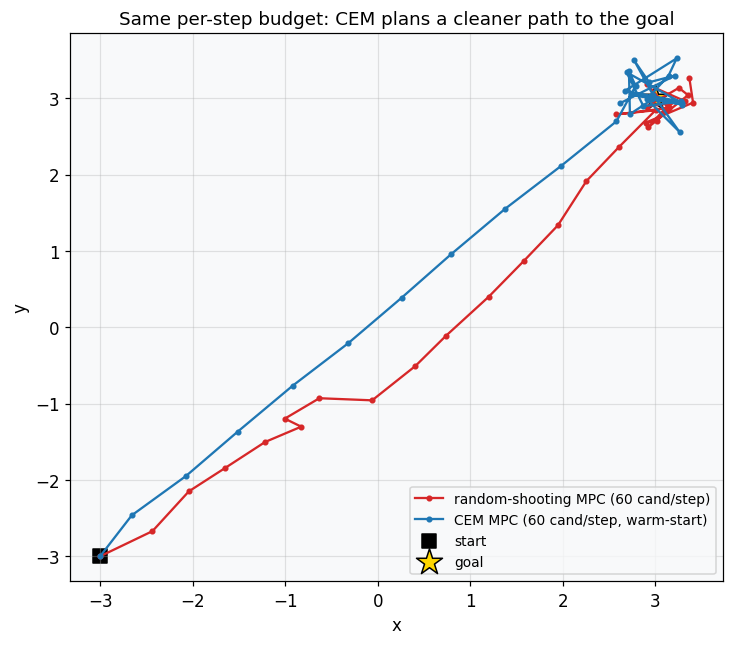

In [9]:
fig, ax = plt.subplots(figsize=(6.8, 6))
ax.plot(traj_shoot[:, 0], traj_shoot[:, 1], '-o', ms=3, color='#d62728',
        label='random-shooting MPC (60 cand/step)')
ax.plot(traj_cem[:, 0], traj_cem[:, 1], '-o', ms=3, color='#1f77b4',
        label='CEM MPC (60 cand/step, warm-start)')
ax.scatter(-3, -3, color='k', s=90, marker='s', label='start')
ax.scatter(*GOAL, color='gold', s=320, marker='*', edgecolor='k', label='goal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Same per-step budget: CEM plans a cleaner path to the goal')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

### What you see

At a tight budget of 60 candidates per step, random-shooting MPC (red) makes noisy progress — with so few
uniform samples per step the best one is often mediocre, so the path wanders. CEM MPC (blue) spends the same
60 candidates across a few refit iterations and warm-starts from the previous plan, producing a straighter,
faster approach to the goal and a smaller final distance.

**Why.** Inside each step CEM concentrates its limited budget on promising action sequences instead of
scattering them, and warm-starting carries the solution forward so each step refines rather than restarts.

**Takeaway.** CEM is a drop-in upgrade to the MPC inner loop: same receding-horizon skeleton, same objective,
better use of a fixed candidate budget. The next note, MPPI, refines this further by softly weighting *all*
candidates instead of hard-selecting an elite set.

## Summary / Key Takeaways

- **Adaptive search (Exp 1)** — CEM keeps a Gaussian belief and refits it to the elite (a maximum-likelihood /
  cross-entropy update), concentrating samples on the optimum over a few iterations.
- **Sample efficiency (Exp 2)** — at equal evaluation budget CEM far outperforms uniform shooting, and the gap
  grows with action-sequence dimension — why PlaNet/PETS use it for latent planning.
- **Variance collapse (Exp 3)** — too greedy an elite fraction collapses the belief and traps CEM in a local
  optimum; variance floors / momentum / colored noise (iCEM) keep exploration alive.
- **MPC optimizer (Exp 4)** — dropped into the receding-horizon loop with warm-starting, CEM reaches the goal
  with fewer candidates than random shooting; MPPI (next) refines the elite step into a soft weighting.